In [1]:
import pandas as pd

df = pd.read_csv('aice_day9_customer_churn.csv')

In [2]:
df.head()

,customer_id,age,gender,monthly_fee,usage_time,contract_type,support_count,churn
0,C10001,45.0,Male,64900.0,140.7,One-year,3.0,0
1,C10002,29.0,Female,101700.0,20.4,Two-year,3.0,0
2,C10003,50.0,Male,90200.0,94.6,Monthly,2.0,0
3,C10004,52.0,Female,62400.0,107.3,Monthly,1.0,0
4,C10005,18.0,Female,84500.0,81.5,One-year,3.0,0


In [3]:
df.isnull().sum()

customer_id       0
age              14
gender            7
monthly_fee      11
usage_time       16
contract_type     6
support_count     0
churn             0
dtype: int64

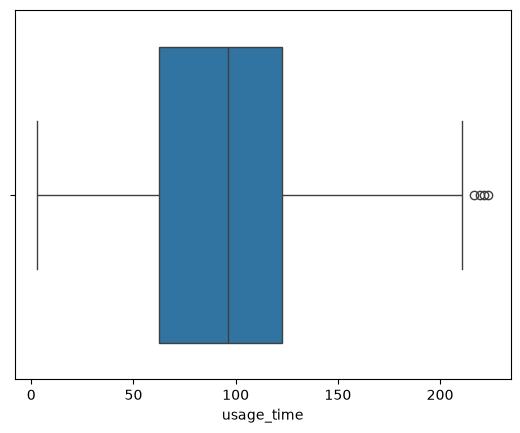

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.boxplot(data=df, x='usage_time')
plt.show()

<Axes: xlabel='monthly_fee'>

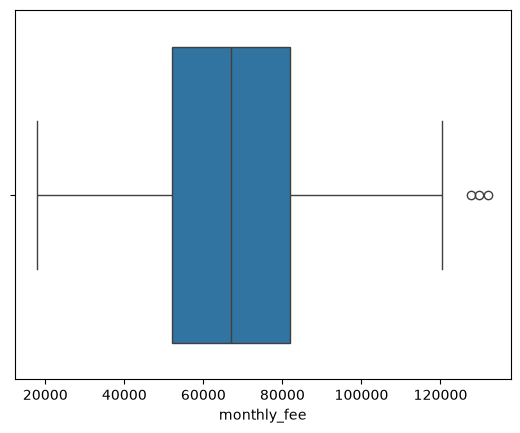

In [6]:
sns.boxplot(data=df, x='monthly_fee')

In [8]:
df.describe()

,age,monthly_fee,usage_time,support_count,churn
count,586.000000,589.000000,584.000000,600.000000,600.000000
mean,40.827645,66713.242784,93.461301,1.626667,0.176667
std,11.487458,22896.610149,44.045464,1.365184,0.381705
min,18.000000,18000.000000,3.000000,0.000000,0.000000
25%,33.000000,52000.000000,62.450000,1.000000,0.000000
50%,41.000000,67100.000000,96.450000,1.000000,0.000000
75%,48.000000,81800.000000,122.425000,2.000000,0.000000
max,75.000000,132100.000000,223.600000,8.000000,1.000000


In [9]:
df['churn'].value_counts()

churn
0    494
1    106
Name: count, dtype: int64

In [13]:
print(df['gender'].value_counts(dropna=False), '\n')
print(df['contract_type'].value_counts(dropna=False), '\n')
print(df['churn'].value_counts(), '\n')
print(df['churn'].value_counts(normalize=True), '\n')

gender
Male      299
Female    294
NaN         7
Name: count, dtype: int64 

contract_type
Monthly     300
One-year    191
Two-year    103
NaN           6
Name: count, dtype: int64 

churn
0    494
1    106
Name: count, dtype: int64 

churn
0    0.823333
1    0.176667
Name: proportion, dtype: float64 



In [25]:
#print(df.sort_values('age', ascending=False).head(10))
#print(df.sort_values('monthly_fee', ascending=False).head(10))
print(df.sort_values('usage_time', ascending=False).head(10))

    customer_id   age  gender  monthly_fee  usage_time contract_type  \
264      C10265  47.0  Female      59300.0       223.6      One-year   
377      C10378  18.0    Male      42400.0       221.6       Monthly   
547      C10548  29.0    Male      37900.0       219.5       Monthly   
353      C10354  51.0  Female      73200.0       216.7      One-year   
507      C10508  46.0    Male      57800.0       210.8       Monthly   
575      C10576  24.0  Female      44900.0       208.9       Monthly   
342      C10343  42.0    Male      74800.0       200.2       Monthly   
498      C10499  18.0    Male      73500.0       197.5       Monthly   
529      C10530  60.0  Female      81300.0       195.5      One-year   
210      C10211  52.0     NaN      37000.0       194.6      Two-year   

     support_count  churn  
264            1.0      0  
377            1.0      0  
547            2.0      0  
353            2.0      0  
507            1.0      0  
575            0.0      0  
342        

In [28]:
df['age'] = df['age'].fillna(df['age'].mean())
df['monthly_fee'] = df['monthly_fee'].fillna(df['monthly_fee'].mean())
df['usage_time'] = df['usage_time'].fillna(df['usage_time'].median())
df['gender'] = df['gender'].fillna(df['gender'].mode().iloc[0])
df['contract_type'] = df['contract_type'].fillna(df['contract_type'].mode().iloc[0])

In [29]:
df.isnull().sum()

customer_id      0
age              0
gender           0
monthly_fee      0
usage_time       0
contract_type    0
support_count    0
churn            0
dtype: int64

In [30]:
df['gender'] = df['gender'].map({
    'Male':0,
    'Female':1
})

In [ ]:
# true / false 값 int로 변경
# df = df.astype({  
#     'contract_type_Monthly': 'int',
#     'contract_type_One-year': 'int',
#     'contract_type_Two-year': 'int'
#     })

df.head()

,age,gender,monthly_fee,usage_time,support_count,churn,contract_type_Monthly,contract_type_One-year,contract_type_Two-year
0,45.0,0,64900.0,140.7,3.0,0,0,1,0
1,29.0,1,101700.0,20.4,3.0,0,0,0,1
2,50.0,0,90200.0,94.6,2.0,0,1,0,0
3,52.0,1,62400.0,107.3,1.0,0,1,0,0
4,18.0,1,84500.0,81.5,3.0,0,0,1,0


In [38]:
df = df.drop(columns='customer_id')

In [40]:
x = df.drop(columns='churn')
y = df['churn']

In [43]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [44]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [46]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report

model = KNeighborsClassifier(n_neighbors=5)

model.fit(x_train_scaled, y_train)
pred = model.predict(x_test_scaled)

print(confusion_matrix(y_test, pred))
print(classification_report(y_test, pred))


[[94  5]
 [17  4]]
              precision    recall  f1-score   support

           0       0.85      0.95      0.90        99
           1       0.44      0.19      0.27        21

    accuracy                           0.82       120
   macro avg       0.65      0.57      0.58       120
weighted avg       0.78      0.82      0.79       120



In [48]:
from sklearn.model_selection import GridSearchCV

params = {'n_neighbors':[1,3,5,7,9,11,13]}

grid = GridSearchCV(
    KNeighborsClassifier(),
    params,
    cv=5,
    scoring='recall'
)

grid.fit(x_train_scaled, y_train)

print(grid.best_params_)
print(grid.best_score_)


{'n_neighbors': 1}
0.24705882352941178


In [49]:
from sklearn.linear_model import LogisticRegression

logi_model = LogisticRegression(class_weight='balanced')

logi_model.fit(x_train_scaled,y_train)
logi_pred = logi_model.predict(x_test_scaled)

print(confusion_matrix(y_test, logi_pred))
print(classification_report(y_test, logi_pred))

[[64 35]
 [ 4 17]]
              precision    recall  f1-score   support

           0       0.94      0.65      0.77        99
           1       0.33      0.81      0.47        21

    accuracy                           0.68       120
   macro avg       0.63      0.73      0.62       120
weighted avg       0.83      0.68      0.71       120



In [54]:
from sklearn.metrics import roc_auc_score, recall_score, precision_score

proba = logi_model.predict_proba(x_test_scaled)[:,1]

threshold = [0.3, 0.5, 0.7]

for th in threshold:
    proba_pred = (proba>=th).astype(int)

    print(confusion_matrix(y_test, proba_pred))
    print(recall_score(y_test, proba_pred))
    print(precision_score(y_test, proba_pred))



[[40 59]
 [ 0 21]]
1.0
0.2625
[[64 35]
 [ 4 17]]
0.8095238095238095
0.3269230769230769
[[87 12]
 [10 11]]
0.5238095238095238
0.4782608695652174


In [57]:
knn_proba = model.predict_proba(x_test_scaled)[:,1]
logi_proba = logi_model.predict_proba(x_test_scaled)[:,1]

print(roc_auc_score(y_test, knn_proba))
print(roc_auc_score(y_test, logi_proba))

0.7282347282347281
0.8061568061568061
